In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# Cats vs Dogs CNN Classifier - Dataset Exploration

This notebook explores the Cats vs Dogs image dataset before building a CNN model.

The goal of the project is to classify images as either cat or dog using a Convolutional Neural Network (CNN).

In [2]:
from pathlib import Path
import os
import random

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
# Find project root from the notebook location
PROJECT_ROOT = Path.cwd().parents[1]

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "dogcat"

TRAIN_DIR = DATA_DIR / "train"
VALIDATION_DIR = DATA_DIR / "validation"
TEST_DIR = DATA_DIR / "test1" / "test1"
SUBMISSION_FILE = DATA_DIR / "sampleSubmission.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory exists:", DATA_DIR.exists())
print("Train directory exists:", TRAIN_DIR.exists())
print("Validation directory exists:", VALIDATION_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())
print("Submission file exists:", SUBMISSION_FILE.exists())

Project root: c:\Users\mahta\aidev\cats-dogs-cnn-classifier
Data directory exists: True
Train directory exists: True
Validation directory exists: True
Test directory exists: True
Submission file exists: True


In [4]:
def count_images(folder_path):
    """Count image files in a folder."""
    image_extensions = {".jpg", ".jpeg", ".png"}
    return len([
        file for file in Path(folder_path).iterdir()
        if file.suffix.lower() in image_extensions
    ])


train_cats = count_images(TRAIN_DIR / "cats")
train_dogs = count_images(TRAIN_DIR / "dogs")

val_cats = count_images(VALIDATION_DIR / "cats")
val_dogs = count_images(VALIDATION_DIR / "dogs")

test_images = count_images(TEST_DIR)

dataset_counts = pd.DataFrame({
    "Dataset part": ["Train", "Train", "Validation", "Validation", "Test"],
    "Class": ["cats", "dogs", "cats", "dogs", "unknown"],
    "Number of images": [train_cats, train_dogs, val_cats, val_dogs, test_images]
})

dataset_counts

,Dataset part,Class,Number of images
0,Train,cats,12500
1,Train,dogs,12500
2,Validation,cats,4000
3,Validation,dogs,4000
4,Test,unknown,12500


## Dataset structure

The dataset is divided into training, validation and test folders.  
The training and validation folders contain two classes: cats and dogs.  
The test folder contains images without class labels, so it will be used for prediction examples rather than final model evaluation.

This is a binary image classification problem where the goal is to classify each image as either cat or dog.

## Dataset balance

The dataset is well balanced in both the training and validation sets.

The training set contains 12,500 cat images and 12,500 dog images.  
The validation set contains 4,000 cat images and 4,000 dog images.

This is useful because the model gets an equal number of examples from both classes during training.  
The test folder contains 12,500 images, but these images do not have labels in separate folders. Therefore, the test folder will be used only for prediction examples, not for calculating final accuracy.

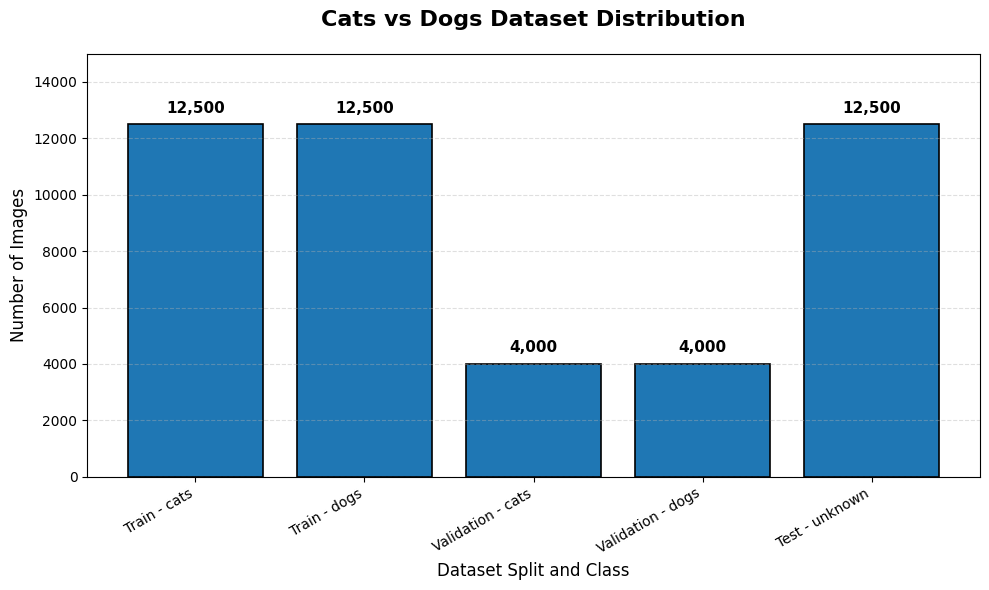

In [ ]:
# Prepare data for visualization
plot_data = dataset_counts.copy()
plot_data["Label"] = plot_data["Dataset part"] + " - " + plot_data["Class"]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    plot_data["Label"],
    plot_data["Number of images"],
    edgecolor="black",
    linewidth=1.2
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 300,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Cats vs Dogs Dataset Distribution",
    fontsize=16,
    fontweight="bold",
    pad=20
)


plt.xlabel("Dataset Split and Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.ylim(0, plot_data["Number of images"].max() + 2500)

plt.tight_layout()
plt.show()

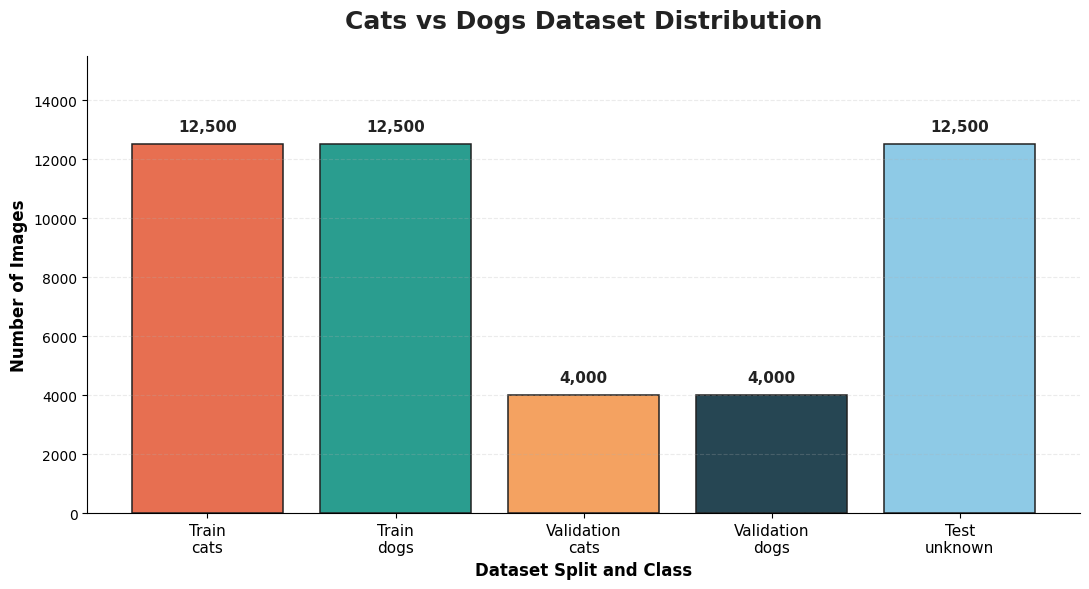

In [8]:
# Beautiful class distribution visualization

plot_data = dataset_counts.copy()
plot_data["Label"] = plot_data["Dataset part"] + "\n" + plot_data["Class"]

# Custom colors for a more polished visual style
colors = [
    "#E76F51",  # Train cats - warm coral
    "#2A9D8F",  # Train dogs - teal
    "#F4A261",  # Validation cats - soft orange
    "#264653",  # Validation dogs - dark blue/green
    "#8ECAE6"   # Test unknown - light blue
]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    plot_data["Label"],
    plot_data["Number of images"],
    color=colors,
    edgecolor="#222222",
    linewidth=1.1
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 350,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#222222"
    )

plt.title(
    "Cats vs Dogs Dataset Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#222222"
)

plt.subtitle = None

plt.xlabel("Dataset Split and Class", fontsize=12, fontweight="bold")
plt.ylabel("Number of Images", fontsize=12, fontweight="bold")

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.ylim(0, plot_data["Number of images"].max() + 3000)

# Remove unnecessary borders for a cleaner look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

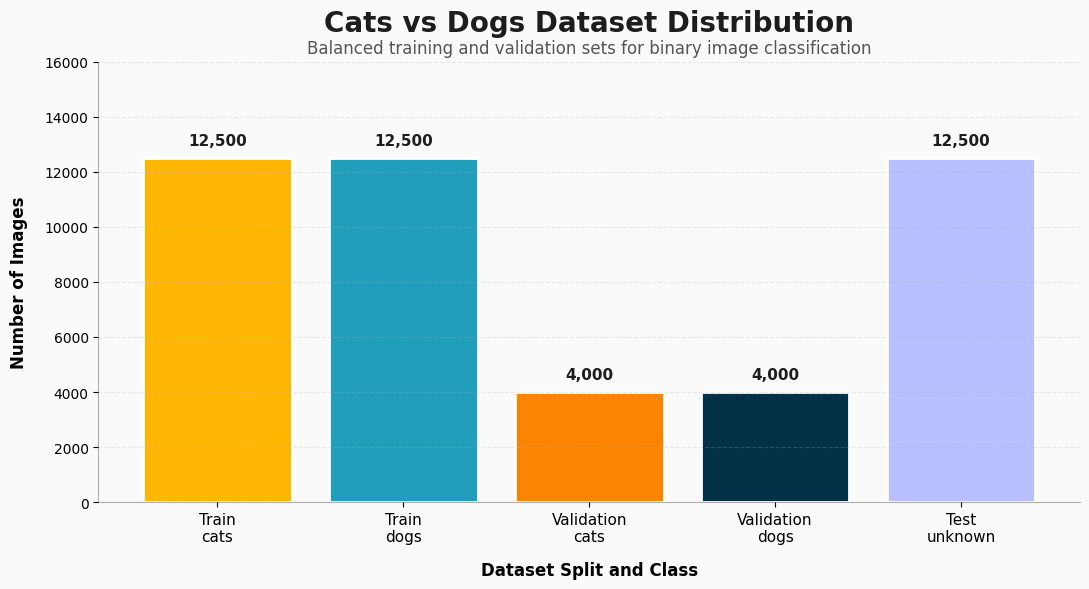

In [9]:
# Premium style dataset distribution chart

plot_data = dataset_counts.copy()
plot_data["Label"] = plot_data["Dataset part"] + "\n" + plot_data["Class"]

colors = {
    "Train cats": "#FFB703",
    "Train dogs": "#219EBC",
    "Validation cats": "#FB8500",
    "Validation dogs": "#023047",
    "Test unknown": "#B8C0FF"
}

bar_colors = [
    colors[f"{row['Dataset part']} {row['Class']}"]
    for _, row in plot_data.iterrows()
]

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

bars = ax.bar(
    plot_data["Label"],
    plot_data["Number of images"],
    color=bar_colors,
    edgecolor="white",
    linewidth=2
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 350,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#1D1D1D"
    )

ax.set_title(
    "Cats vs Dogs Dataset Distribution",
    fontsize=20,
    fontweight="bold",
    pad=22,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Balanced training and validation sets for binary image classification",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_xlabel("Dataset Split and Class", fontsize=12, fontweight="bold", labelpad=12)
ax.set_ylabel("Number of Images", fontsize=12, fontweight="bold", labelpad=12)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_ylim(0, plot_data["Number of images"].max() + 3500)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(
    FIGURES_DIR / "dataset_class_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

## Class distribution

The dataset is balanced in the training and validation sets.  
Both cats and dogs have the same number of images in each split.

This is a strong starting point for training a CNN model because the model receives an equal amount of examples from both classes.  
The test set contains unlabeled images and will therefore be used for prediction examples rather than final evaluation.

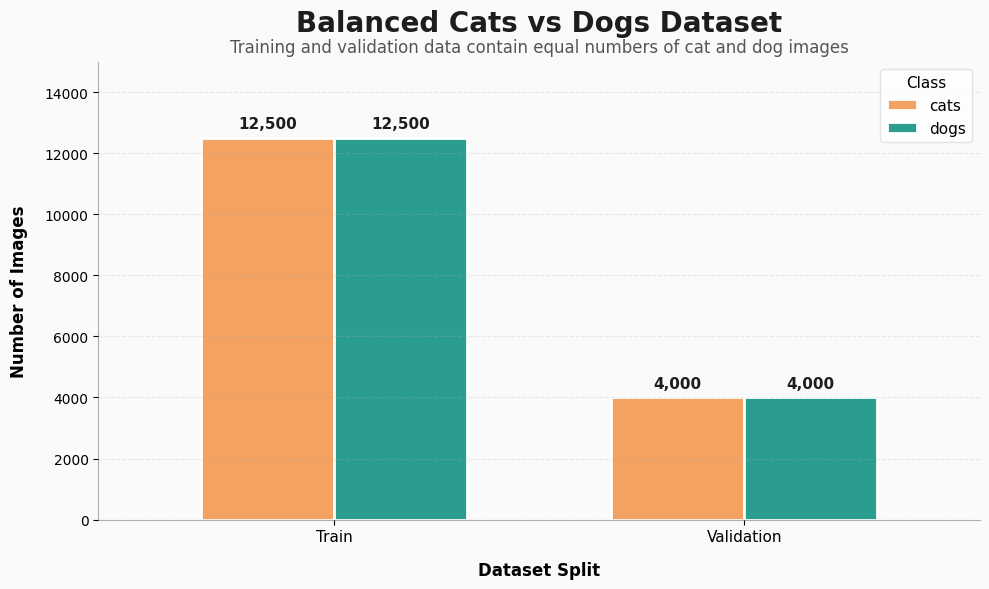

In [12]:
# Premium grouped chart for Cats vs Dogs dataset balance

plot_data = dataset_counts[
    dataset_counts["Dataset part"].isin(["Train", "Validation"])
].copy()

# Pivot data for grouped bar chart
pivot_data = plot_data.pivot(
    index="Dataset part",
    columns="Class",
    values="Number of images"
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

colors = ["#F4A261", "#2A9D8F"]  # cats, dogs

bars = pivot_data.plot(
    kind="bar",
    ax=ax,
    color=colors,
    edgecolor="white",
    linewidth=2,
    width=0.65
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{int(v):,}" for v in container.datavalues],
        padding=5,
        fontsize=11,
        fontweight="bold",
        color="#1D1D1D"
    )

ax.set_title(
    "Balanced Cats vs Dogs Dataset",
    fontsize=20,
    fontweight="bold",
    pad=22,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Training and validation data contain equal numbers of cat and dog images",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_xlabel("Dataset Split", fontsize=12, fontweight="bold", labelpad=12)
ax.set_ylabel("Number of Images", fontsize=12, fontweight="bold", labelpad=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.tick_params(axis="y", labelsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_ylim(0, pivot_data.values.max() + 2500)

ax.legend(
    title="Class",
    title_fontsize=11,
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#DDDDDD"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

plt.tight_layout()
plt.show()

The test folder contains 12,500 unlabeled images.  
Because the test images are not divided into cat and dog folders, they will be used for prediction examples rather than final model evaluation.

In [13]:
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(
    FIGURES_DIR / "balanced_cats_dogs_dataset.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

## Dataset balance

The training and validation sets are balanced.  
The training set contains 12,500 cat images and 12,500 dog images.  
The validation set contains 4,000 cat images and 4,000 dog images.

This is a strong starting point for CNN training because the model receives the same number of examples from both classes.  
A balanced dataset reduces the risk that the model becomes biased toward one class.

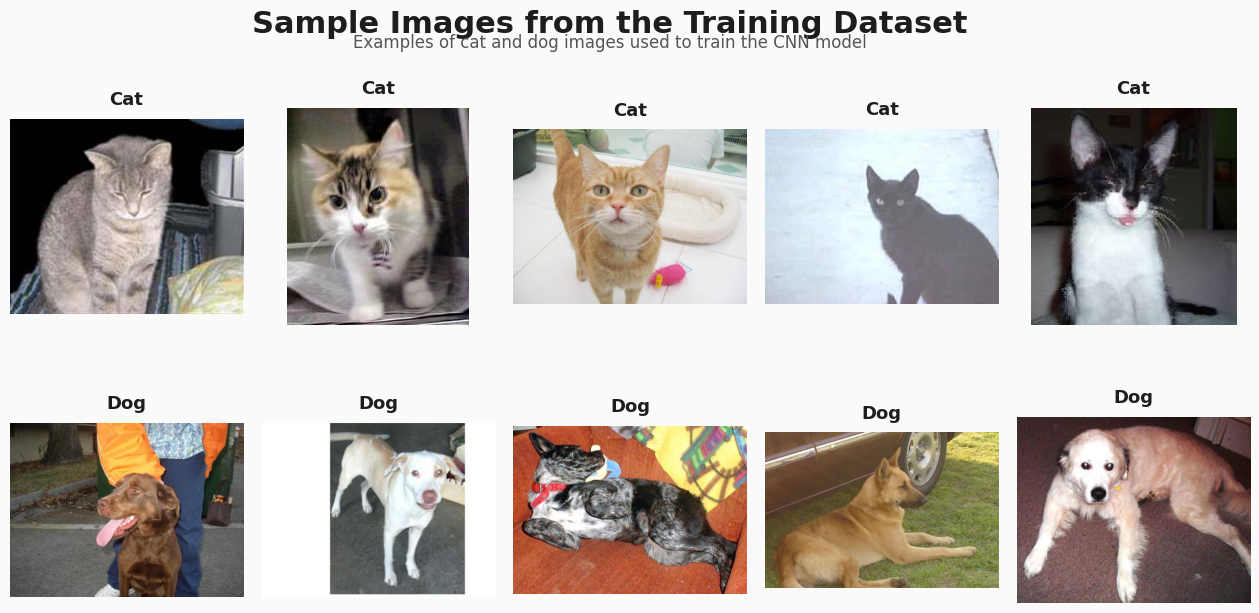

In [20]:
# Show sample cat and dog images in a cleaner presentation-friendly layout

cat_images = get_random_images(TRAIN_DIR / "cats", n=5)
dog_images = get_random_images(TRAIN_DIR / "dogs", n=5)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.patch.set_facecolor("#FAFAFA")

for row, image_paths, label in [
    (0, cat_images, "Cat"),
    (1, dog_images, "Dog")
]:
    for col, image_path in enumerate(image_paths):
        img = Image.open(image_path).convert("RGB")
        
        axes[row, col].imshow(img)
        axes[row, col].set_title(
            label,
            fontsize=13,
            fontweight="bold",
            pad=10,
            color="#1D1D1D"
        )
        axes[row, col].axis("off")

# Main title
fig.suptitle(
    "Sample Images from the Training Dataset",
    fontsize=22,
    fontweight="bold",
    y=0.98,
    color="#1D1D1D"
)

# Subtitle
fig.text(
    0.5,
    0.925,
    "Examples of cat and dog images used to train the CNN model",
    ha="center",
    fontsize=12,
    color="#555555"
)

plt.subplots_adjust(
    top=0.84,
    hspace=0.35,
    wspace=0.08
)

plt.show()

## Sample image observations

The sample images show that the dataset contains many real-world variations.  
The animals appear in different positions, backgrounds, lighting conditions and image qualities.

Some images contain more than one animal, and some animals are close to the camera while others are further away.  
This makes the classification task more realistic and also more challenging.

A CNN model is suitable for this task because it can learn visual patterns such as edges, textures, fur, ears, eyes, noses and body shapes.

In [21]:
def get_image_sizes(folder_path, max_images=None):
    """Return image sizes from a folder as a list of (width, height)."""
    image_extensions = {".jpg", ".jpeg", ".png"}
    image_paths = [
        path for path in Path(folder_path).iterdir()
        if path.suffix.lower() in image_extensions
    ]
    
    if max_images:
        image_paths = image_paths[:max_images]
    
    sizes = []
    
    for image_path in image_paths:
        try:
            with Image.open(image_path) as img:
                sizes.append(img.size)  # (width, height)
        except Exception as error:
            print(f"Could not read image: {image_path.name} - {error}")
    
    return sizes


cat_sizes = get_image_sizes(TRAIN_DIR / "cats", max_images=1000)
dog_sizes = get_image_sizes(TRAIN_DIR / "dogs", max_images=1000)

image_sizes_df = pd.DataFrame(cat_sizes + dog_sizes, columns=["width", "height"])

image_sizes_df.describe()

,width,height
count,2000.000000,2000.000000
mean,406.422000,361.615000
std,109.135962,95.681431
min,42.000000,38.000000
25%,332.000000,304.000000
50%,450.000000,374.000000
75%,499.000000,423.000000
max,500.000000,500.000000


## Image size observations

The image size analysis shows that the images have different dimensions.  
Some images are small, while others are much larger.

CNN models require all input images to have the same shape.  
Therefore, all images will be resized to a fixed size before training.

For this project, we will start with an image size of 128x128 pixels.  
This is a good choice because it keeps enough visual information while making training faster on a CPU.

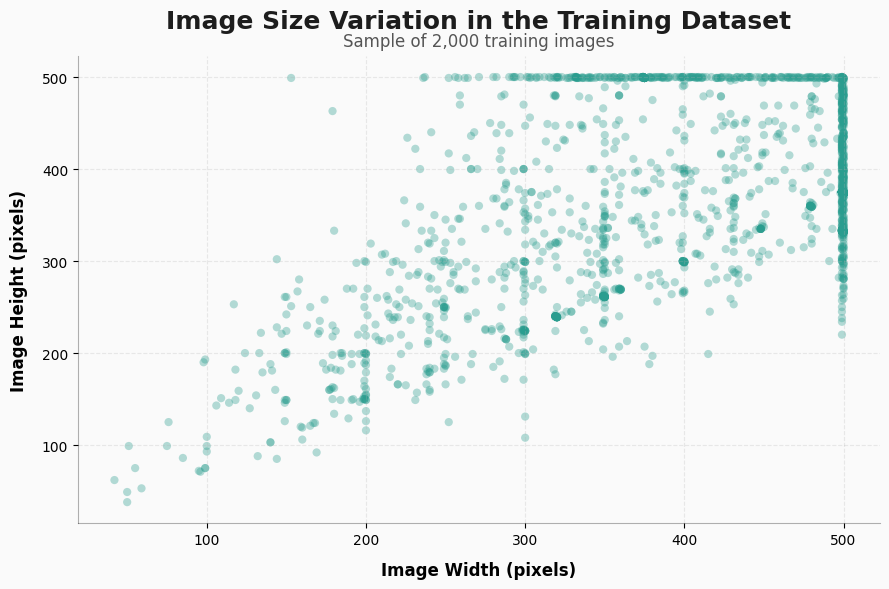

In [22]:
# Visualize image size variation

fig, ax = plt.subplots(figsize=(9, 6))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

ax.scatter(
    image_sizes_df["width"],
    image_sizes_df["height"],
    alpha=0.35,
    s=35,
    color="#2A9D8F",
    edgecolors="none"
)

ax.set_title(
    "Image Size Variation in the Training Dataset",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Sample of 2,000 training images",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_xlabel("Image Width (pixels)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Image Height (pixels)", fontsize=12, fontweight="bold", labelpad=10)

ax.grid(True, linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

plt.tight_layout()
plt.show()

In [23]:
fig.savefig(
    FIGURES_DIR / "image_size_variation.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

## Image size variation

The scatter plot shows that the training images have different widths and heights.  
Some images are very small, while many images are close to 500 pixels in width or height.

This means that the images cannot be sent directly into a CNN model without preprocessing.  
CNN models require all input images to have the same shape.

In this project, all images will be resized to 128x128 pixels before training.  
This size is a practical choice because it keeps useful visual information while reducing training time on a CPU.

In [24]:
submission_df = pd.read_csv(SUBMISSION_FILE)

print("Shape:", submission_df.shape)
submission_df.head()

Shape: (12500, 2)


,id,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [25]:
submission_df["label"].value_counts()

label
0    12500
Name: count, dtype: int64

## Test data and sample submission

The test folder contains 12,500 images, and the sampleSubmission.csv file contains 12,500 rows.

However, the label column only contains the value 0 for all rows.  
This means that the file is only a submission template and does not contain the true labels for the test images.

Because of this, the test set cannot be used to calculate final accuracy, confusion matrix or classification report.  
Instead, the validation set will be used for model evaluation, while the test images can be used for prediction examples.

## Preprocessing plan

Before training the CNN model, the images need to be prepared.

The preprocessing steps will be:

1. Resize all images to 128x128 pixels.
2. Convert images to RGB format with 3 color channels.
3. Normalize pixel values from the range 0-255 to the range 0-1.
4. Load the images in batches to avoid memory problems.
5. Use the validation set to monitor model performance during training.

These steps are necessary because CNN models require input images with the same shape and numerical scale.

In [26]:
# Image preprocessing settings

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Seed:", SEED)

Image size: (128, 128)
Batch size: 32
Seed: 42


In [28]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 25000 files belonging to 2 classes.


In [29]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 8000 files belonging to 2 classes.


In [30]:
class_names = train_dataset.class_names
print("Class names:", class_names)

Class names: ['cats', 'dogs']


In [31]:
# Inspect one batch from the training dataset

for images, labels in train_dataset.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy().flatten())

Images batch shape: (32, 128, 128, 3)
Labels batch shape: (32, 1)
First 10 labels: [0. 0. 1. 0. 0. 0. 1. 0. 1. 0.]


In [32]:
# Check pixel value range before normalization

for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", images.numpy().min())
    print("Maximum pixel value:", images.numpy().max())

Minimum pixel value: 0.0
Maximum pixel value: 255.0


## TensorFlow dataset inspection

The images were successfully loaded with TensorFlow using `image_dataset_from_directory`.

Each batch contains 32 images, and each image has the shape 128x128x3.  
This means that all images have been resized to the same width and height and are represented as RGB images with three color channels.

The labels are binary because the project has two classes: cats and dogs.

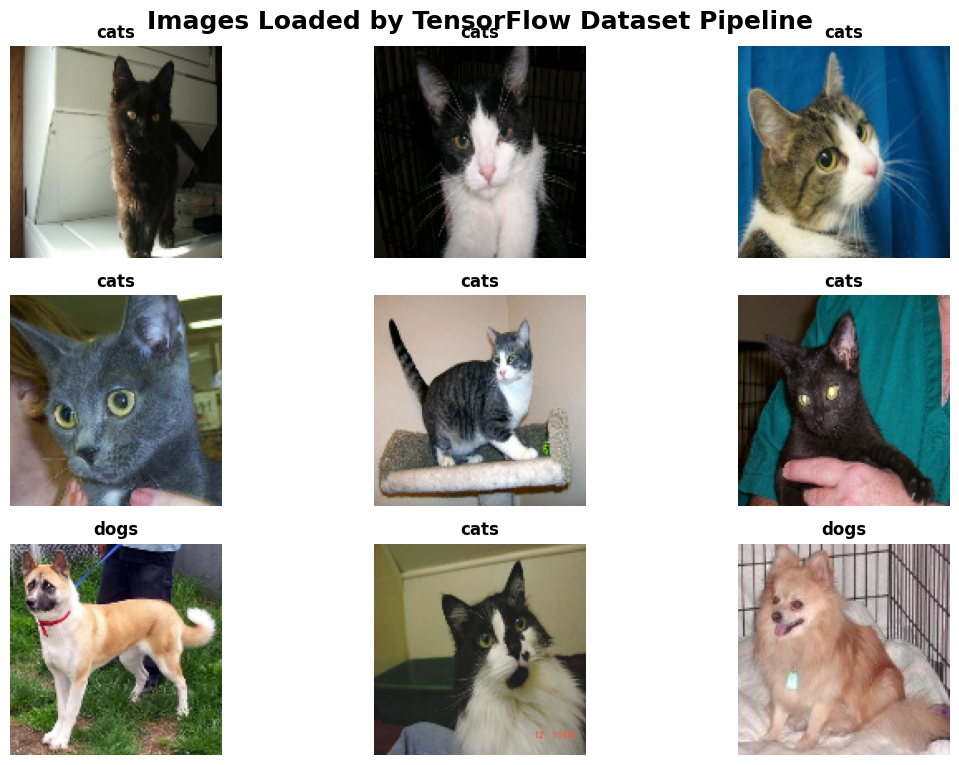

In [33]:
# Visualize images loaded by TensorFlow with their labels

plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        plt.imshow(images[i].numpy().astype("uint8"))
        
        label_index = int(labels[i].numpy()[0])
        plt.title(
            class_names[label_index],
            fontsize=12,
            fontweight="bold"
        )
        
        plt.axis("off")

plt.suptitle(
    "Images Loaded by TensorFlow Dataset Pipeline",
    fontsize=18,
    fontweight="bold",
    y=0.95
)

plt.tight_layout()
plt.show()

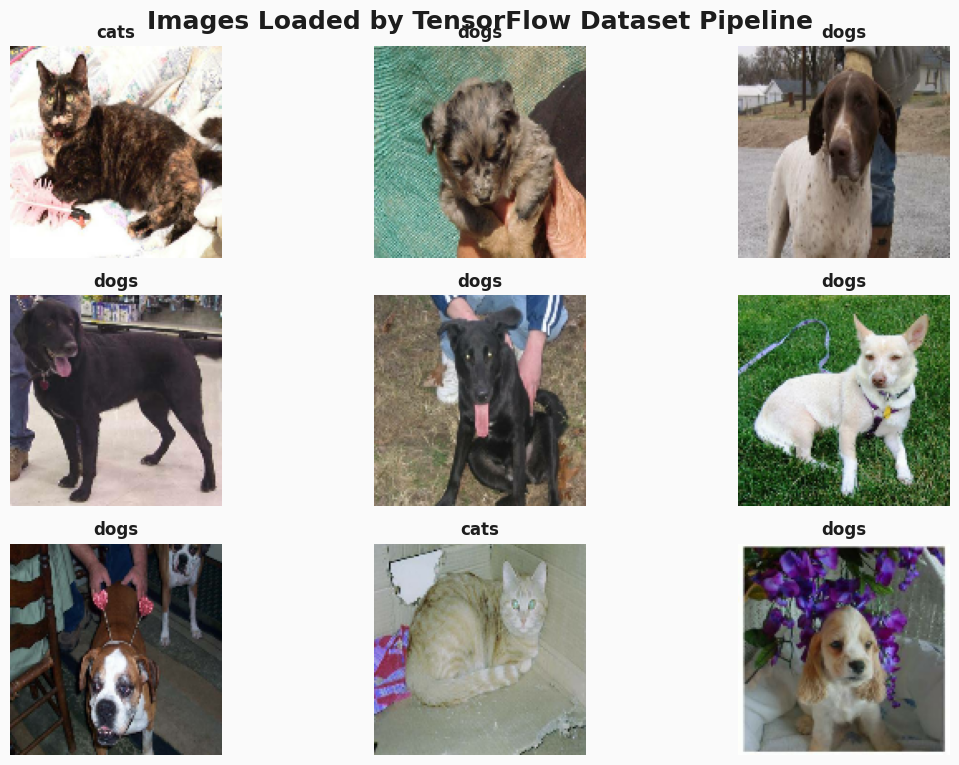

In [34]:
# Visualize and save images loaded by TensorFlow with their labels

fig = plt.figure(figsize=(12, 8))
fig.patch.set_facecolor("#FAFAFA")

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        plt.imshow(images[i].numpy().astype("uint8"))
        
        label_index = int(labels[i].numpy()[0])
        plt.title(
            class_names[label_index],
            fontsize=12,
            fontweight="bold",
            color="#1D1D1D"
        )
        
        plt.axis("off")

plt.suptitle(
    "Images Loaded by TensorFlow Dataset Pipeline",
    fontsize=18,
    fontweight="bold",
    y=0.95,
    color="#1D1D1D"
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "tensorflow_loaded_images.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

## TensorFlow loading check

The images were successfully loaded from the folder structure using TensorFlow.  
The labels were automatically inferred from the folder names: cats and dogs.

This confirms that the dataset pipeline works correctly and that the images are ready to be used for CNN model training.